In [48]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

data=pd.read_csv("loan_data.csv")

X=data.drop("loan_status",axis=1)
y=data["loan_status"]
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ada_model=AdaBoostClassifier(n_estimators=100,
                             random_state=42)

ada_model.fit(X_train,y_train)

y_pred=ada_model.predict(X_test)

accuracy_adaboost = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance of adaboost model")
print("------------------")
print(f"Accuracy : {accuracy_adaboost*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

gb_model=GradientBoostingClassifier(n_estimators=100,
                                    learning_rate=0.1,
                                    random_state=42)
gb_model.fit(X_train,y_train)
y_pred=gb_model.predict(X_test)

accuracy_gboost = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance of gradientboost model")
print("------------------")
print(f"Accuracy : {accuracy_gboost*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))



from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions on Test Data
y_pred = model.predict(X_test)

# Metrics
accuracy_logi = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance of logistic")
print("------------------")
print(f"Accuracy : {accuracy_logi*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predictions on Test Data
y_pred = model.predict(X_test)

# Metrics
accuracy_knn = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance of knn")
print("------------------")
print(f"Accuracy : {accuracy_knn*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

xgb_model=XGBClassifier(n_estimators=100,
                        learning_rate=0.1,
                        max_depth=3,
                        use_label_encoder=False,
                        eval_metric="mlogloss",
                        random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

accuracy_xgboost = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance of XGboost model")
print(f"Accuracy : {accuracy_xgboost*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

import joblib

joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Model saved successfully!")



Model Performance of adaboost model
------------------
Accuracy : 90.79%
Precision: 80.93%
Recall   : 76.87%
F1 Score : 78.85%

Confusion Matrix
[[6626  364]
 [ 465 1545]]

Model Performance of gradientboost model
------------------
Accuracy : 92.09%
Precision: 86.96%
Recall   : 75.97%
F1 Score : 81.09%

Confusion Matrix
[[6761  229]
 [ 483 1527]]

Model Performance of logistic
------------------
Accuracy : 89.44%
Precision: 77.52%
Recall   : 74.28%
F1 Score : 75.86%

Confusion Matrix
[[6557  433]
 [ 517 1493]]

Model Performance of knn
------------------
Accuracy : 88.93%
Precision: 79.37%
Recall   : 68.16%
F1 Score : 73.34%

Confusion Matrix
[[6634  356]
 [ 640 1370]]

Model Performance of XGboost model
Accuracy : 92.28%
Precision: 87.17%
Recall   : 76.72%
F1 Score : 81.61%

Confusion Matrix
[[6763  227]
 [ 468 1542]]
Model saved successfully!


c:\Users\OM SONI\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:54:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


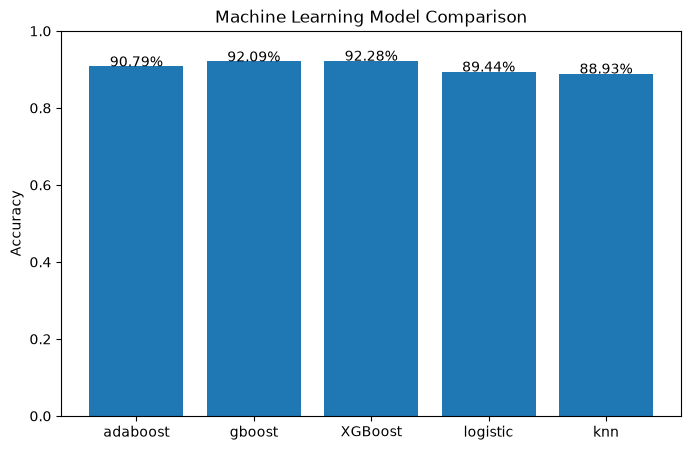

In [26]:
models = ['adaboost', 'gboost', 'XGBoost',"logistic","knn"]
accuracies = [accuracy_adaboost, accuracy_gboost, accuracy_xgboost,accuracy_logi,accuracy_knn]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f'{bar.get_height()*100:.2f}%',
             ha='center')

plt.ylabel("Accuracy")
plt.title("Machine Learning Model Comparison")
plt.ylim(0, 1)
plt.show()

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64


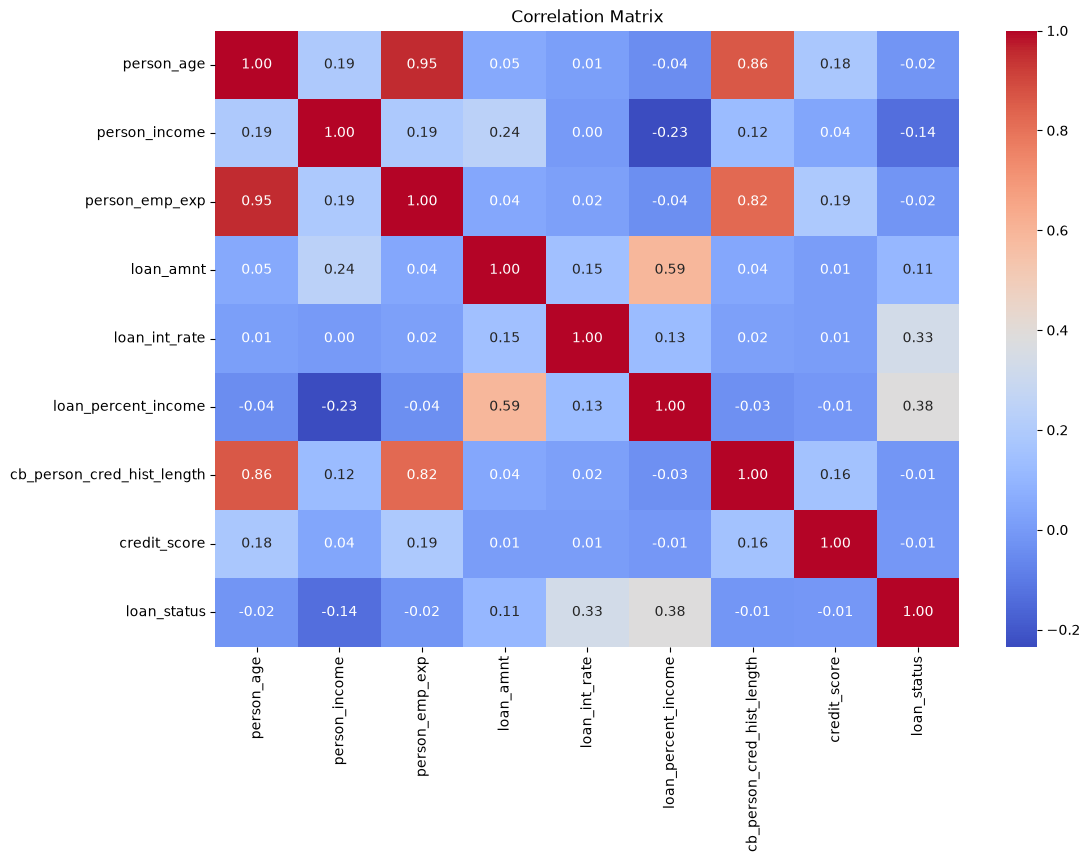

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
data.dtypes
data.head()

corr = data.corr(numeric_only=True)["loan_status"].sort_values(ascending=False)

print(corr)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()


In [46]:
person_age = int(input("Enter Age: "))
person_gender = input("Enter Gender (male/female): ").strip().lower()
person_education = input(
    "Education (Master, High School, Bachelor, Associate, Doctorate): "
).strip().title()

person_income = float(input("Enter Income: "))
person_emp_exp = int(input("Enter Employment Experience: "))
person_home_ownership = input(
    "Home Ownership (RENT, OWN, MORTGAGE, OTHER): "
).strip().upper()
loan_amnt = float(input("Enter Loan Amount: "))

loan_intent = input(
    "Loan Intent (PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION): "
).strip().upper()
loan_int_rate = float(input("Enter Loan Interest Rate: "))
loan_percent_income = float(input("Enter Loan Percent Income: "))
cb_person_cred_hist_length = int(input("Enter Credit History Length: "))
credit_score = int(input("Enter Credit Score: "))
previous_loan_defaults_on_file = input(
    "Previous Loan Default (Yes/No): "
).strip().title()

import pandas as pd

user_data = pd.DataFrame({
    "person_age": [person_age],
    "person_gender": [person_gender],
    "person_education": [person_education],
    "person_income": [person_income],
    "person_emp_exp": [person_emp_exp],
    "person_home_ownership": [person_home_ownership],
    "loan_amnt": [loan_amnt],
    "loan_intent": [loan_intent],
    "loan_int_rate": [loan_int_rate],
    "loan_percent_income": [loan_percent_income],
    "cb_person_cred_hist_length": [cb_person_cred_hist_length],
    "credit_score": [credit_score],
    "previous_loan_defaults_on_file": [previous_loan_defaults_on_file]
})

user_data = pd.get_dummies(user_data)
user_data = user_data.reindex(columns=X.columns, fill_value=0)
user_data = scaler.transform(user_data)

prediction = model.predict(user_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")
    
prediction = model.predict(user_data)
probability = model.predict_proba(user_data)
print("\nProbability of Rejection :", probability[0][0] * 100, "%")
print("Probability of Approval  :", probability[0][1] * 100, "%")

Loan Approved

Probability of Rejection : 20.0 %
Probability of Approval  : 80.0 %


In [45]:
print(data["person_gender"].unique())
print(data["person_education"].unique())
print(data["person_home_ownership"].unique())
print(data["loan_intent"].unique())
print(data["previous_loan_defaults_on_file"].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str
<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str
<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
